<a href="https://colab.research.google.com/github/WellingtonRoque/POO/blob/main/Aula3_Exce%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tratamento de Erros Personalizados e Internos em Python com POO**

# **1. Introdução ao Tratamento de Erros**

Erros ocorrem quando um programa encontra uma situação inesperada.

Em Python, quando um erro acontece, uma **exceção** é lançada, interrompendo a execução do código.

Por exemplo, se tentarmos dividir um número por zero, Python lança a exceção **`ZeroDivisionError:`**

In [14]:
print(10 / 0)  # ZeroDivisionError: division by zero



ZeroDivisionError: division by zero

Para evitar que o programa **pare inesperadamente**, usamos **try-except**, que permite capturar erros e tratá-los de forma controlada.

**Exemplo: Tratando Erro de Divisão por Zero (ZeroDivisionError)**

In [ ]:
try:
    resultado = 10 / 0  # Tentativa de divisão por zero
except ZeroDivisionError as erro:
    print(f"Erro: {erro}. Não é possível dividir por zero!")


Erro: division by zero. Não é possível dividir por zero!


**Explicação do Código**

* O bloco **try** tenta executar a divisão 10 / 0, o que normalmente geraria um erro **(ZeroDivisionError)**.
* O bloco **except** captura esse erro e imprime uma mensagem personalizada sem interromper o programa.
* **`as erro`** armazena a mensagem do erro original para que possamos exibi-la.

**Exemplo: Tratamento de Erro ao Converter Entrada (ValueError)**

In [5]:

numero = int(input("Digite um número: "))
print(f"Você digitou: {numero}")



Digite um número: t


ValueError: invalid literal for int() with base 10: 't'

In [4]:
try:
    # Solicita um número inteiro do usuário
    numero = int(input("Digite um número: "))

    # Se a conversão for bem-sucedida, imprime o número
    print(f"Você digitou: {numero}")

except ValueError:
    # Captura erro caso o usuário insira algo que não seja um número inteiro
    print("Erro: Você deve digitar um número válido.")


Digite um número: 7.9
Erro: Você deve digitar um número válido.


**📖 Explicação Passo a Passo**

**1️⃣ Entrada do usuário**

O programa solicita que o usuário insira um número usando input().
Como input() sempre retorna uma string, precisamos convertê-la para int().

**2️⃣ Bloco try**

Tenta converter a entrada para inteiro (int).
Se a conversão for bem-sucedida, exibe a mensagem "Você digitou: X".

**3️⃣ Bloco except ValueError**

Caso o usuário digite algo que não seja um número inteiro (exemplo: "abc" ou "3.14"), o Python gera um erro **ValueError**.
O except captura esse erro e exibe uma mensagem personalizada.

**🔄 Variação com while para Repetir até Entrada Correta**

Podemos aprimorar o código para garantir que o usuário só saia quando digitar um número válido.

In [8]:
while True:
    try:
        numero = int(input("Digite um número: "))
        print(f"Você digitou: {numero}")
        break  # Sai do loop se a entrada for válida
    except ValueError:
        print("Erro: Você deve digitar um número válido. Tente novamente.")


Digite um número: t
Erro: Você deve digitar um número válido. Tente novamente.
Digite um número: y
Erro: Você deve digitar um número válido. Tente novamente.
Digite um número: u
Erro: Você deve digitar um número válido. Tente novamente.
Digite um número: 5
Você digitou: 5


# **2. Usando raise para Lançar Exceções em Python**

O comando **raise** é utilizado para forçar a ocorrência de uma exceção, permitindo que o desenvolvedor interrompa a execução do programa quando uma condição específica for encontrada.

Isso é útil para:

* Validar dados antes de processá-los.
* Evitar operações inválidas que poderiam gerar erros inesperados.
* Criar exceções personalizadas para situações específicas no código.

**Exemplo Básico do raise**

In [13]:
def dividir(a, b):
    if b == 0:
        raise ZeroDivisionError("Não é possível dividir por zero.")
    return a / b

# Teste
#print(dividir(10, 2))  # Saída: 5.0
print(dividir(10, 0))  # Gera ZeroDivisionError


ZeroDivisionError: Não é possível dividir por zero.

**Explicação**

* Se b == 0, o programa não tenta fazer a divisão.
* Em vez disso, lançamos um erro manualmente com raise **ZeroDivisionError** ("Não é possível dividir por zero.").
* Se b for diferente de 0, a função retorna o resultado normalmente.

**Usando raise para Validar Dados de Entrada**

O raise pode ser usado para garantir que o usuário forneça valores corretos.

In [12]:
def definir_idade(idade):
    if idade < 0:
        raise ValueError("A idade não pode ser negativa.")
    return f"Idade registrada: {idade} anos"

# Testes
print(definir_idade(25))  # OK
#print(definir_idade(-5))  # Gera ValueError


Idade registrada: 25 anos


ValueError: A idade não pode ser negativa.

**Explicação**
* Se idade for negativa, o programa não permite continuar e gera um erro com raise ValueError("A idade não pode ser negativa.").
* Isso evita que dados inválidos sejam armazenados ou usados no sistema.

# **3. Criando Exceções Personalizadas**

Podemos criar nossas próprias **classes de exceção**, herdando da **classe Exception**.

In [15]:
class SaldoInsuficienteError(Exception):
    """Exceção personalizada para saldo insuficiente."""
    pass

def sacar(valor, saldo):
    if valor > saldo:
        raise SaldoInsuficienteError("Saldo insuficiente para essa operação.")
    return f"Saque de R${valor:.2f} realizado com sucesso."

# Testes
print(sacar(50, 100))  # OK
#print(sacar(150, 100))  # Gera SaldoInsuficienteError


Saque de R$50.00 realizado com sucesso.


**Primeiro: Exceções Personalizadas**
```
class SaldoInsuficienteError(Exception):
    """Exceção personalizada para saldo insuficiente."""
    pass
```

**Explicação**

* Aqui, você está criando uma nova exceção chamada **SaldoInsuficienteError**.
* Ela herda de **Exception**, que é a **classe base** para todas as exceções em Python.
* Como herda de **Exception**, a sua exceção pode ser usada no try/except, ser lançada com raise, e funcionar como qualquer erro padrão.
* O **`pass`** é porque, por enquanto, não estamos mudando nada no comportamento dela — só estamos usando para ter um nome próprio e uma mensagem própria.

**Resumindo**: Você criou o seu próprio tipo de erro!

**Depois: A função sacar**

```
def sacar(valor, saldo):
    if valor > saldo:
        raise SaldoInsuficienteError("Saldo insuficiente para essa operação.")
    return f"Saque de R${valor:.2f} realizado com sucesso."
```

* A função `sacar` recebe dois parâmetros: o valor que a pessoa quer sacar e o saldo disponível.
* Ela verifica: **se o valor pedido for maior que o saldo**, acontece um **raise**.
* **raise = lançar uma exceção**. Aqui, você está levantando o seu erro personalizado **SaldoInsuficienteError** e passando uma mensagem para ele.
* Se o **saldo for suficiente**, ele retorna uma mensagem dizendo que o saque foi realizado.

**Por fim: os Testes**

```
print(sacar(50, 100))  # OK
print(sacar(150, 100))  # Gera SaldoInsuficienteError

```

* No primeiro print, o **saque de R$50** é permitido (saldo é 100), então a função retorna sucesso.

* No segundo print, o s**aque de R$150 é maior** que o saldo de 100, então o raise é executado → e isso gera a exceção **SaldoInsuficienteError**.

* Se você rodar assim, vai acontecer um erro no console porque a exceção não está sendo tratada **(try/except)**.

**Exemplo melhorado com tratamento**

In [16]:
try:
    print(sacar(50, 100))  # OK
    print(sacar(150, 100))  # Vai gerar exceção
except SaldoInsuficienteError as e:
    print(f"Erro: {e}")


Saque de R$50.00 realizado com sucesso.
Erro: Saldo insuficiente para essa operação.


* Agora, o erro é capturado **(except SaldoInsuficienteError)** e a mensagem **"Saldo insuficiente para essa operação."** é exibida, sem quebrar o programa.

# **4. Capturando Exceções com try-except após um raise**

Quando usamos raise, é importante capturar a exceção para evitar que o programa seja encerrado abruptamente.

In [18]:
def definir_idade(idade):
    """Função que valida a idade e levanta uma exceção se for inválida."""
    if idade < 0:
        raise ValueError("A idade não pode ser negativa.")  # Lançando a exceção
    return f"Idade registrada: {idade} anos"

try:
    idade_usuario = int(input("Digite sua idade: "))
    resultado = definir_idade(idade_usuario)  # Pode gerar ValueError
    print(resultado)

except ValueError as erro:
    print(f"Erro ao registrar idade: {erro}")  # Capturando e tratando o erro



Digite sua idade: -56
Erro ao registrar idade: A idade não pode ser negativa.


**Explicação Passo a Passo**

**1️⃣ Função definir_idade(idade)**

Se idade for **menor que 0**, usamos **raise** para lançar um **ValueError** com uma mensagem personalizada.
Caso contrário, retorna a idade registrada.

**2️⃣ Bloco try**

O programa solicita ao usuário um número inteiro para representar a idade.
Chama a função **definir_idade(idade_usuario)**, que pode lançar uma exceção.

**3️⃣ Bloco except ValueError as erro**

Se a **função lançar um erro**, ele será capturado aqui.
O erro é exibido com uma mensagem amigável para o usuário.

**🔄 Variação com while para Repetir até Entrada Correta**

Podemos modificar o código para forçar o usuário a digitar um valor válido.

In [21]:
def definir_idade(idade):
    if idade < 0:
        raise ValueError("A idade não pode ser negativa.")
    return f"Idade registrada: {idade} anos"

while True:
    try:
        idade_usuario = int(input("Digite sua idade: "))
        resultado = definir_idade(idade_usuario)
        print(resultado)
        break  # Sai do loop se a entrada for válida
    except ValueError as erro:
        print(f"Erro: {erro}. Tente novamente.")


Digite sua idade: -6
Erro: A idade não pode ser negativa.. Tente novamente.
Digite sua idade: =9
Erro: invalid literal for int() with base 10: '=9'. Tente novamente.
Digite sua idade: 7
Idade registrada: 7 anos


# **5. Bloco else e finally no Tratamento de Exceções**

**1. Bloco else**

O **bloco else** é executado apenas se **nenhum erro** ocorrer dentro do **bloco try**. Ele é útil quando queremos executar algum código **apenas** quando a execução do bloco try for **bem-sucedida**, ou seja, **não gerou exceções**.

**2. Bloco finally**

O **bloco finally** é sempre executado independentemente de **ocorrer ou não uma exceção**. Ele é usado para realizar ações de limpeza ou de finalização, como fechar arquivos, liberar recursos ou imprimir mensagens finais. Mesmo que uma **exceção** tenha sido **gerada** e **capturada**, o código dentro de **finally sempre será executado**.

# **O Bloco else**

O bloco else é executado apenas se nenhum erro ocorrer dentro do try.

In [23]:
try:
    numero = int(input("Digite um número: "))
except ValueError:
    print("Erro: Você deve digitar um número válido.")
else:
    print(f"O dobro do número digitado é {numero * 2}.")


Digite um número: A
Erro: Você deve digitar um número válido.


🔹 Se o usuário digitar um **número válido**, o bloco else será executado.

🔹 Se um erro ocorrer **(ValueError)**, o else será ignorado.

# **O Bloco finally**

O **bloco finally** é executado sempre, independentemente de ocorrer um **erro ou não**. Isso é útil para liberar recursos, como fechar arquivos ou conexões.

In [25]:
try:
    arquivo = open("dados.txt", "r")
    conteudo = arquivo.read()
    print(conteudo)
except FileNotFoundError:
    print("Erro: O arquivo não foi encontrado.")
finally:
    print("Operação finalizada.")  # Sempre será executado


Erro: O arquivo não foi encontrado.
Operação finalizada.


**Exemplo Completo com else e finally**

In [26]:
def dividir(a, b):
    """Função que tenta realizar uma divisão e captura erros."""
    try:
        # Tentativa de realizar a divisão
        resultado = a / b
    except ZeroDivisionError:
        # Captura o erro caso o denominador seja zero
        print("Erro: Não é possível dividir por zero.")
    else:
        # Executado se não houver exceção (se a divisão for bem-sucedida)
        print(f"Resultado da divisão: {resultado}")
    finally:
        # Sempre será executado, independentemente de erro ou sucesso
        print("Operação de divisão finalizada.")

# Testando o código
dividir(10, 2)  # Divisão bem-sucedida
#dividir(10, 0)  # Erro de divisão por zero


Resultado da divisão: 5.0
Operação de divisão finalizada.


**Explicação do Exemplo**

**1. Função dividir(a, b)**
* O programa tenta realizar a divisão de a por b no bloco try.
* Se o denominador for zero, o erro ZeroDivisionError é capturado no bloco except.
* Se não ocorrer erro, o bloco else exibe o resultado da divisão.
* Independentemente de erro ou sucesso, o bloco finally é sempre executado, permitindo que a mensagem "Operação de divisão finalizada." seja impressa.

**Detalhamento do Fluxo de Execução**

**Bloco try**
* O código dentro de try é executado normalmente.
* Se não houver erro, o fluxo segue para o bloco else.
* Caso ocorra uma exceção, o fluxo é interrompido, e o código do bloco except será executado.

**Bloco else**
* O código dentro de else é executado apenas quando o bloco try não gera exceção.
* No exemplo acima, se a divisão for bem-sucedida, o resultado da divisão é impresso aqui.
* Importante: O bloco else não será executado se houver exceção no try.

**Bloco finally**
* O código dentro de finally será executado independentemente de erro ou sucesso.
* Usamos esse bloco para garantir que ações importantes, como liberar recursos (ex: fechar arquivos, conexões de banco de dados, etc.), sempre ocorram, mesmo se um erro for gerado.
* No exemplo, o print("Operação de divisão finalizada.") será sempre impresso, não importa se a operação de divisão falhou ou não.

**🔄 Exemplo de Uso Prático: Finalizando Arquivos**

Um exemplo clássico do uso de finally é quando trabalhamos com arquivos. Queremos garantir que, mesmo que ocorra um erro ao ler ou escrever no arquivo, o arquivo seja fechado corretamente.

In [ ]:
def ler_arquivo(nome_arquivo):
    try:
        arquivo = open(nome_arquivo, 'r')
        conteudo = arquivo.read()
        print(conteudo)
    except FileNotFoundError:
        print("Erro: O arquivo não foi encontrado.")
    else:
        print("Arquivo lido com sucesso.")
    finally:
        arquivo.close()
        print("Arquivo fechado.")

# Teste com um arquivo inexistente
ler_arquivo("arquivo_inexistente.txt")


**Explicação**

**Bloco try:** Tenta abrir o arquivo e ler seu conteúdo.

**Bloco except:** Se o arquivo não for encontrado (FileNotFoundError), imprime uma mensagem de erro.

**Bloco else:** Se o arquivo for lido com sucesso, imprime que a leitura foi bem-sucedida.

**Bloco finally:** O arquivo é fechado, independentemente de ter ocorrido erro ou não.

**📌 Resumo**

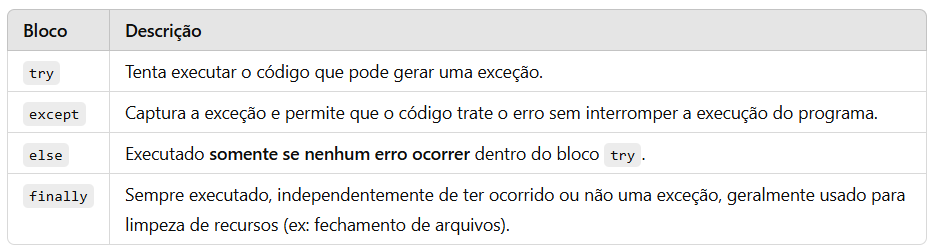



**📌 Conclusão**

O bloco **else** é útil para executar código quando não há erros no try, mantendo o fluxo do programa mais limpo.

O bloco **finally** garante que certas ações (como fechar arquivos ou liberar recursos) sejam sempre realizadas, independentemente de erros no código.

Usar esses blocos corretamente melhora a **robustez e a manutenibilidade** do seu código.

# **6. Aplicando POO ao Tratamento de Erros**

Em Python, os **erros e exceções** são tratados utilizando o b**loco try/except**, que permite capturar problemas em **tempo de execução** e evitar que o programa **pare abruptamente**.

Com o uso da **Programação Orientada a Objetos (POO)**, é possível criar **exceções personalizadas**, deixando o tratamento de erros mais organizado, inteligente e fácil de manter.

Assim como criamos **classes** para modelar entidades no nosso sistema **(como Cliente, Conta, Produto)**, também podemos criar **classes de erro que herdam da classe base Exception**.

**Conceito de Exceções Personalizadas**

Em POO, podemos criar nossas próprias c**lasses de exceção**.
Essas classes **herdam da classe Exception**, que é a classe-pai de **todos os erros em Python**.

**Criar exceções próprias nos ajuda a:**

* Identificar erros mais facilmente;

* Tratar diferentes tipos de erro de forma separada;

* Tornar o código mais claro e profissional.

# **Como Criar uma Exceção Personalizada**

Uma **exceção** personalizada é criada como qualquer outra classe, mas **herdando de Exception**.

**Exemplo básico:**

```
class SaldoInsuficienteError(Exception):
    """Exceção para saldo insuficiente em operações bancárias."""
    pass

```

Aqui, **SaldoInsuficienteError** é um novo tipo de erro que podemos usar para situações específicas no nosso sistema, como tentativas de saque sem saldo suficiente.



**Exemplo Completo: Aplicando POO no Tratamento de Erros**

Vamos simular um **Sistema Bancário** com **diferentes tipos de erros**.




In [27]:
# Definindo exceções personalizadas
class SaldoInsuficienteError(Exception):
    """Erro lançado quando o saldo não é suficiente para o saque."""
    pass

class ValorInvalidoError(Exception):
    """Erro lançado quando o valor informado é inválido."""
    pass

# Função que usa essas exceções
def sacar(valor, saldo):
    if valor <= 0:
        raise ValorInvalidoError("O valor do saque deve ser positivo.")
    if valor > saldo:
        raise SaldoInsuficienteError("Saldo insuficiente para essa operação.")
    return f"Saque de R${valor:.2f} realizado com sucesso."

# Testando o saque
try:
    print(sacar(50, 100))   # Saque válido
    print(sacar(-20, 100))  # Valor inválido
except ValorInvalidoError as erro:
    print(f"Erro de valor: {erro}")
except SaldoInsuficienteError as erro:
    print(f"Erro de saldo: {erro}")
except Exception as erro:
    print(f"Erro inesperado: {erro}")


Saque de R$50.00 realizado com sucesso.
Erro de valor: O valor do saque deve ser positivo.


**Vantagens de Aplicar POO no Tratamento de Erros**

✅ **Organização**: Cada erro tem uma classe específica, facilitando o entendimento.

✅ **Precisão**: Permite capturar tipos de erros diferentes em blocos separados.

✅ **Reutilização**: Exceções personalizadas podem ser usadas em vários pontos do sistema.

✅ **Manutenção**: Quando há mudanças no sistema, é mais fácil localizar e atualizar o tratamento dos erros.

**Dicas Importantes**

✅ Sempre que for criar uma **exceção**, **herde da classe Exception**.

✅ Escreva uma **docstring** explicando o motivo da exceção.

✅ Use **exceções personalizadas** para erros previsíveis no seu domínio de aplicação.

✅ Capriche nas **mensagens de erro!** Elas ajudam no **debug** e na experiência de quem usa o sistema.



# **7. Aplicações Práticas do Tratamento de Erros com POO**

Aqui estão algumas aplicações reais do que foi aprendido:

**1️⃣ Validação de Entrada de Usuário**

📌 **Aplicação**: Evita que usuários insiram dados inválidos, garantindo um fluxo correto no sistema.

In [ ]:
def obter_numero():
    while True:
        try:
            num = int(input("Digite um número: "))
            return num
        except ValueError:
            print("Entrada inválida! Tente novamente.")

numero = obter_numero()
print(f"Você digitou: {numero}")


**2️⃣ Verificação de Acesso a Arquivos**

📌 **Aplicação**: Impede que um erro de arquivo interrompa a execução do programa.

In [28]:
def ler_arquivo(nome_arquivo):
    try:
        with open(nome_arquivo, "r") as arquivo:
            return arquivo.read()
    except FileNotFoundError:
        return "Erro: Arquivo não encontrado."
    finally:
        print("Tentativa de leitura concluída.")

conteudo = ler_arquivo("meuarquivo.txt")
print(conteudo)


Tentativa de leitura concluída.
Erro: Arquivo não encontrado.


**3️⃣ Validação de Login**

📌 **Aplicação**: Simula um sistema de login, garantindo que senhas incorretas sejam tratadas sem expor informações sensíveis.

In [ ]:
class CredenciaisInvalidasError(Exception):
    pass

def autenticar(usuario, senha):
    usuarios = {"admin": "1234", "user": "abcd"}
    if usuario not in usuarios or usuarios[usuario] != senha:
        raise CredenciaisInvalidasError("Usuário ou senha incorretos!")
    return "Login realizado com sucesso!"

try:
    usuario = input("Usuário: ")
    senha = input("Senha: ")
    print(autenticar(usuario, senha))
except CredenciaisInvalidasError as e:
    print(f"Erro de autenticação: {e}")


# **Lista de Exercícios de Exceções e Orientação a Objetos (POO)**

Esses exercícios cobrem conceitos de **tratamento de exceções, raise, else, finally, criação de classes, herança, métodos personalizados e exceções customizadas**, proporcionando uma abordagem prática, diversificada e robusta.

**1. Tratamento Básico de Exceções**

**Tarefa**: Crie uma função que recebe dois números e tenta retornar a divisão entre eles. Capture erro de divisão por zero.

**Objetivo**: Trabalhar com exceções básicas `(ZeroDivisionError)`.


**2. Uso de else**

**Tarefa**: Crie uma função para calcular a média de uma lista de números. Use try-except para capturar erro de tipo, e no bloco else, imprima a média. Obs: Utilizar o **TypeError**: acontece quando você usa tipos errados para uma operação.

**Objetivo**: Praticar o uso do bloco `else` após `try-except`.


**3. Validação de Entrada com try-except**

**Tarefa**: Crie uma função que solicita ao usuário digitar um número inteiro. Garanta o tratamento de erro para valores inválidos.

**Objetivo**: Validar entradas e capturar `ValueError`.

**4. Uso de raise para Lançar Exceções**

**Tarefa**: Crie uma função que recebe a idade de uma pessoa. Se a idade for menor que 0, use **raise** para lançar uma exceção personalizada.

**Objetivo**: Utilizar **raise** para lançar erros.

**5. Validação de CPF com raise e Exceções Personalizadas**

**Tarefa**: Crie uma função que valida um CPF. Se tiver menos de 11 caracteres, lance uma exceção.

**Objetivo**: Trabalhar com exceções personalizadas e **raise**.


**6. Tratamento de Exceção com finally**

**Tarefa**: Crie uma função para abrir e ler um arquivo de texto. Garanta que o arquivo seja fechado usando **finally**.

**Objetivo**: Praticar o uso de **finally** para liberar recursos.

**7. Criação de Classe para Validação de Produto**

**Tarefa**: Crie uma classe **Produto** que receba **nome** e **preço**. Se o preço for negativo, levante uma exceção no método `__init__`.

**Objetivo**: Trabalhar com classes, inicialização e tratamento de erro em atributos.

**8. Classe com Método para Divisão Segura**

**Tarefa**: Crie uma classe **Calculadora** com método `dividir(a, b)`. Lance erro se **b** for zero.

**Objetivo**: Associar tratamento de exceções a métodos de uma classe.

**9. Classe com Validação de Entrada**

**Tarefa**: Crie uma classe **Aluno** com atributos **nome** e **nota**. Implemente um método para validar que **nota** seja um número entre 0 e 10.

**Objetivo**: Validar atributos dentro de classes.

**10. Classe Conta Bancária com Exceções Personalizadas**

**Tarefa**: Crie uma classe **ContaBancaria** que permita depósito e saque. Lance exceções para saques acima do saldo disponível.

**Objetivo**: Aplicar **raise** em métodos de classes.

**11. Herança com Tratamento de Erros**

**Tarefa**: Crie uma classe base **Veiculo** e uma classe derivada **Carro**. No construtor de **Carro**, valide que a quantidade de portas seja maior que zero.

**Objetivo**: Praticar herança e validação.

**12. Verificação de Idade**

**Tarefa**: Crie uma classe Pessoa que recebe o nome e a idade como parâmetros.
No método `verificar_maioridade`, use **try-except** para garantir que a idade seja um número inteiro.

**Objetivo**: Tratar erros de tipo e validar dados numéricos.

**13. Exceção Customizada com Classe**

**Tarefa**: Crie uma exceção personalizada chamada `ErroSaldoInsuficiente` para ser usada na classe **ContaBancaria**.

**Objetivo**: Aprender a criar exceções customizadas em POO.

**14. Tratamento de Vários Erros**

**Tarefa**: Crie uma função que pede dois números e realiza a divisão. Capture **ValueError (entrada inválida)** e **ZeroDivisionError (divisão por zero)**. Utilize `else` e `finally`.

**Objetivo**: Combinar múltiplos tipos de exceções em uma única função.

**15. Classe com Múltiplos Métodos e Exceções**

**Tarefa**: Crie uma classe **Loja** com métodos `adicionar_produto`, `remover_produto` e `listar_produtos`. Lance exceções ao tentar **remover** um produto que não existe.

**Objetivo**: Trabalhar com listas, métodos de classe e tratamento de erro.